## Test multiband streaming 05/26/2026
Band 0 is configured with an LO to read out SQUATs at like 7 GHz. Band 1 is in loopback (center freq of 750 MHz, BW = 500 MHz)

In [1]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
matplotlib.use('module://matplotlib_inline.backend_inline')
import yaml
import time
import pickle as pkl
import os
import sys
import numpy as np
from matplotlib import cm
from scipy import signal
from scipy.signal import butter, welch, filtfilt, periodogram, savgol_filter
import pandas as pd
import glob
from scipy.optimize import curve_fit
from scipy.optimize import fminbound
import scipy.linalg as linalg
import scipy as sp
# sys.path.append("/home/cryo/.local/lib/python3.10/site-packages/")
# import nbimporter

#will need to edit this
sys.path.append('../../Utilities')
# from SignalCore import *

plt.ion()
%matplotlib inline

SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE, family='serif')          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE, labelsize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE, facecolor='white') 

In [2]:
%load_ext Cython

In [3]:
from squat_freqscan_fitter import *

# Import useful wrapper functions

In [4]:
sys.path.append("/home/cryo/docker/pysmurf/dev/v8.0.0-rc3_rfsoc/pysmurf/scratch/adroster")
from utils import *
from parity_timestream import *

## Initialize Pysmurf control instance

In [5]:
import pysmurf.client
import epics
import os
import time

%matplotlib inline

epics_prefix="smurf_server_s3"
config_file=os.path.abspath("/usr/local/src/pysmurf/cfg_files/lab1/experiment_lab1_rfsoc.cfg")
S = pysmurf.client.SmurfControl(epics_root=epics_prefix,cfg_file=config_file,setup=False,make_logfile=False,shelf_manager="shm-smrf-sp01")

## Dump versions of everything
# Python version
print(sys.version)
import pysmurf
pysmurf.__version__
cwd=os.getcwd()
os.chdir('/usr/local/src/pysmurf/')
#print(str(!git branch))
#print(!git rev-parse --short HEAD)
print(S.get_fpga_git_hash_short())
print(S.config.filename)

[ 2026-05-26 23:10:32 ]  ERROR : band 0 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-05-26 23:10:32 ]  ERROR : band 1 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-05-26 23:10:32 ]  ERROR : band 2 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-05-26 23:10:32 ]  ERROR : band 3 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-05-26 23:10:32 ]  ERROR : band 4 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-05-26 23:10:32 ]  ERROR : band 5 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-05-26 23:10:32 ]  ERROR : band 6 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-05-26 23:10:32 ]  ERROR : band 7 is present in pysmurf cfg file, but its bay is not enabled!
3.8.10 (default, Mar 13 2023, 10:26:41) 
[GCC 9.4.0]
9355e2a
/usr/local/src/pysmurf/cfg_files/lab1/experiment_lab1_rfsoc.cfg


## Define LO frequency

In [6]:
LO_freq_MHz = 6700 + 750

## Band 0 settings

In [7]:
S.all_off()

[ 2026-05-26 23:10:34 ]  Turning off tones
[ 2026-05-26 23:10:54 ]  Turning off flux ramp
[ 2026-05-26 23:10:54 ]  Turning off all TES biases


In [8]:
band0 = 0

In [9]:
S.get_band_center_mhz(band=band0)

4250.0

In [10]:
S.set_band_center_mhz(band0,LO_freq_MHz-750)

In [11]:
S.get_band_center_mhz(band=band0)

6700.0

## Band 1 settings

In [12]:
band1 = 1

In [13]:
S.get_band_center_mhz(band=band1)

4750.0

4750 is a legacy number; this band center is 750 MHz

In [14]:
S.set_band_center_mhz(band1, 750)

In [15]:
S.get_band_center_mhz(band=band1)

750.0

## Thru fridge

[ 2026-05-26 23:11:08 ]  Sweeping across frequencies 6450.0MHz to 6950.0MHz. Averaging 1 traces.
[ 2026-05-26 23:11:09 ]  Working on band 0
[ 2026-05-26 23:11:43 ]  serial find freq complete ; etaScanInProgress = 0


/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1402: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ndim = x[:, None].ndim
/usr/lib/python3/dist-packages/matplotlib/axes/_base.py:278: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  y = y[:, np.newaxis]


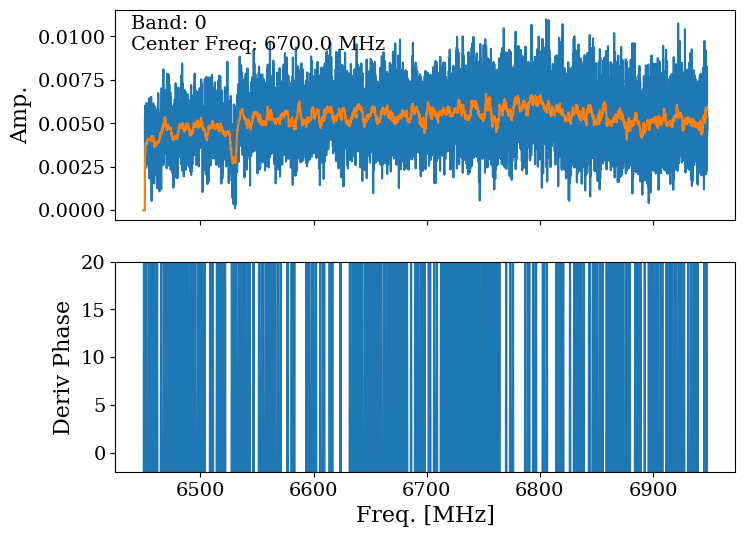

In [16]:
f0, resp0 = freqSweep(S, band=band0, start_freq=-250, stop_freq=250, subband=None, tone_power=12, n_avg = 1
                      , makeplot=True)

[ 2026-05-26 23:11:45 ]  Sweeping across frequencies 500.0MHz to 1000.0MHz. Averaging 1 traces.
[ 2026-05-26 23:11:45 ]  Working on band 1
[ 2026-05-26 23:12:18 ]  serial find freq complete ; etaScanInProgress = 0


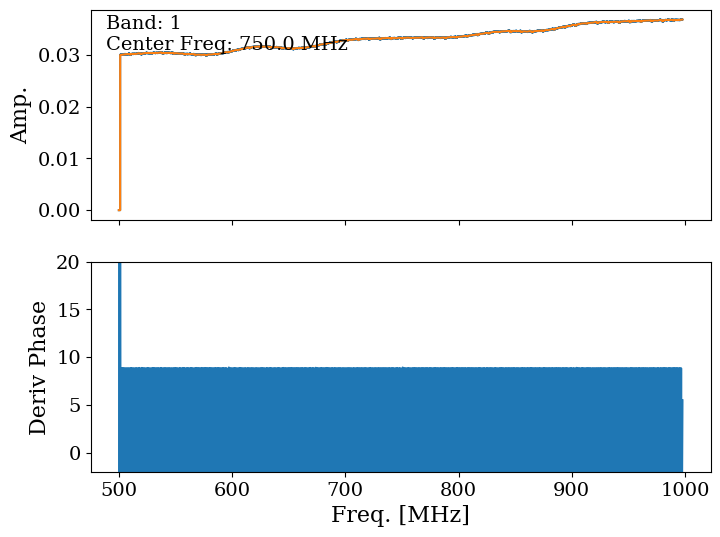

In [17]:
f1, resp1 = freqSweep(S, band=band1, start_freq=-250, stop_freq=250, subband=None, tone_power=12, n_avg = 1
                      , makeplot=True)

## Let's place tones in each band and look for them in the ADC

First make sure everything is off

In [18]:
S.all_off()

[ 2026-05-26 23:12:19 ]  Turning off tones
[ 2026-05-26 23:12:34 ]  Turning off flux ramp
[ 2026-05-26 23:12:34 ]  Turning off all TES biases


In [19]:
S.which_on(band0)

array([], dtype=int64)

In [20]:
S.which_on(band1)

array([], dtype=int64)

[ 2026-05-26 23:12:36 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 524288
[ 2026-05-26 23:12:36 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 0


/usr/local/src/pysmurf/python/pysmurf/client/util/smurf_util.py:1770: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(plot_fn)


[ 2026-05-26 23:12:39 ]  ADC plot saved to /data/smurf_data/20260526/1779837032/plots/1779837156_adc0.png
[ 2026-05-26 23:12:39 ]  Saving raw adc data to /data/smurf_data/20260526/1779837032/outputs/1779837156_adc0


/usr/local/lib/python3.8/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


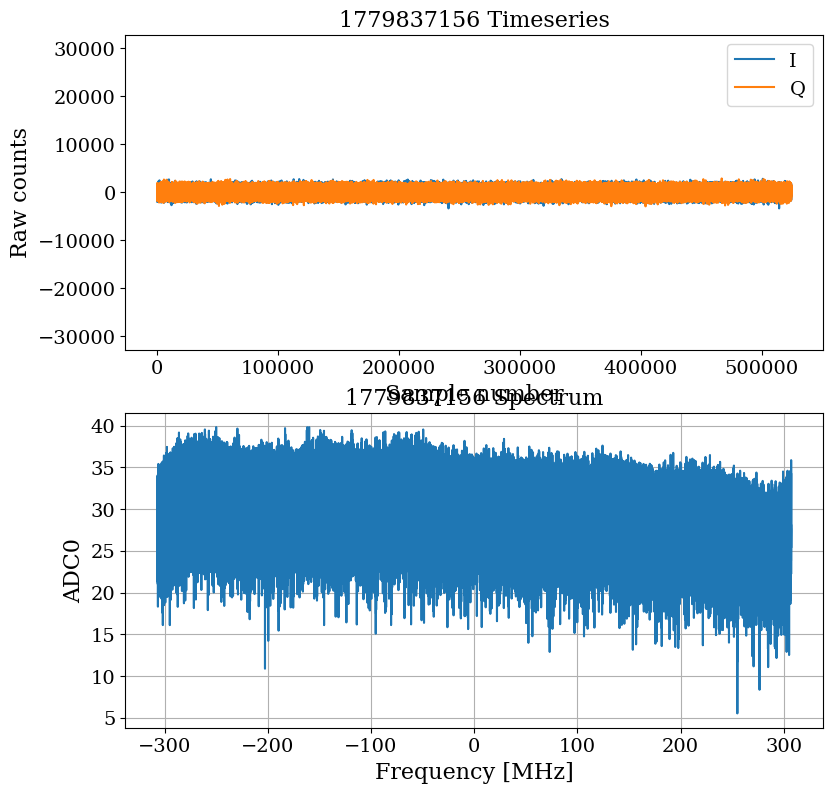

In [21]:
adc=S.read_adc_data(band = band0,make_plot=True,show_plot=True)

Band 0

In [22]:
f_tone0 = 6800
S.set_band_center_mhz(band0,LO_freq_MHz-750)
print(S.get_band_center_mhz(band0))
f_tone0_IF = 750 + (S.get_band_center_mhz(band0) - f_tone0)

6700.0


In [23]:
S.set_band_center_mhz(band0,750)

my_log = f'Sending fixed tone at {f_tone0_IF} MHz'
print(my_log)
# S.log(my_log)
(band0, channel_tone0) = S.set_fixed_tone(f_tone0_IF, 12)

Sending fixed tone at 650.0 MHz


In [24]:
S.which_on(band0)

array([363])

[ 2026-05-26 23:13:35 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 524288
[ 2026-05-26 23:13:35 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 0
[ 2026-05-26 23:13:37 ]  ADC plot saved to /data/smurf_data/20260526/1779837032/plots/1779837216_adc0.png
[ 2026-05-26 23:13:37 ]  Saving raw adc data to /data/smurf_data/20260526/1779837032/outputs/1779837216_adc0


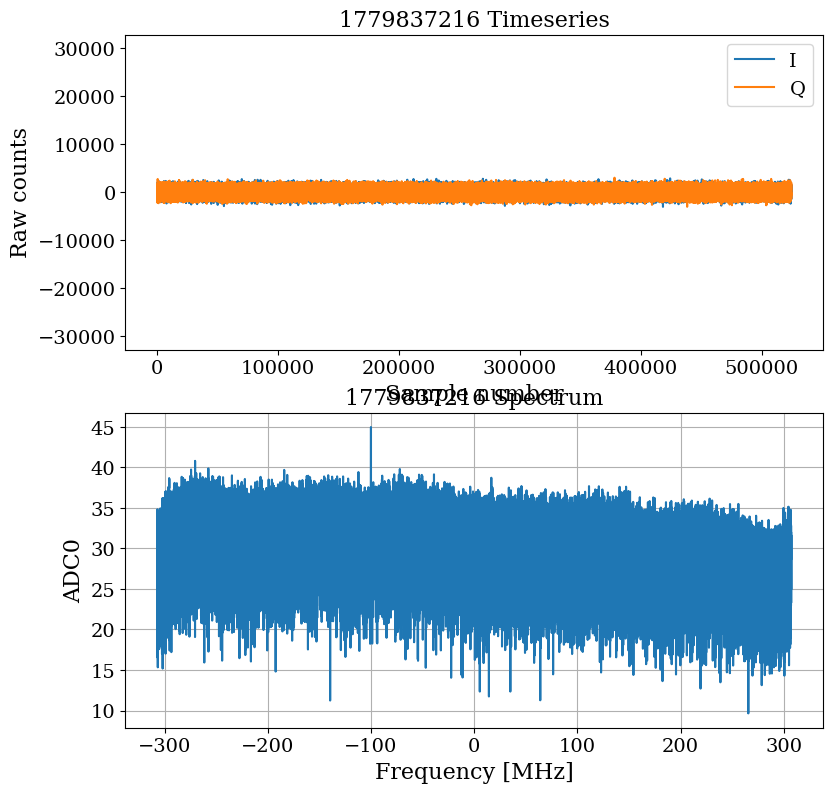

In [25]:
adc=S.read_adc_data(band = band0,make_plot=True,show_plot=True)

Tone is visible, nice

Band 1

In [26]:
f_tone1 = 820
S.set_band_center_mhz(band1, 750)
print(S.get_band_center_mhz(band1))
f_tone1_IF = 750 + (S.get_band_center_mhz(band1) - f_tone1)

750.0


In [27]:
S.set_band_center_mhz(band1,750)

my_log = f'Sending fixed tone at {f_tone1_IF} MHz'
print(my_log)
# S.log(my_log)
(band1, channel_tone1) = S.set_fixed_tone(f_tone1_IF, 12)

Sending fixed tone at 680.0 MHz


In [28]:
S.which_on(band1)

array([199, 363])

[ 2026-05-26 23:13:52 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:DaqMuxV2[0]:DataBufferSize 524288
[ 2026-05-26 23:13:52 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:DebugSelect[0] 0
[ 2026-05-26 23:13:54 ]  ADC plot saved to /data/smurf_data/20260526/1779837032/plots/1779837233_adc0.png
[ 2026-05-26 23:13:54 ]  Saving raw adc data to /data/smurf_data/20260526/1779837032/outputs/1779837233_adc0


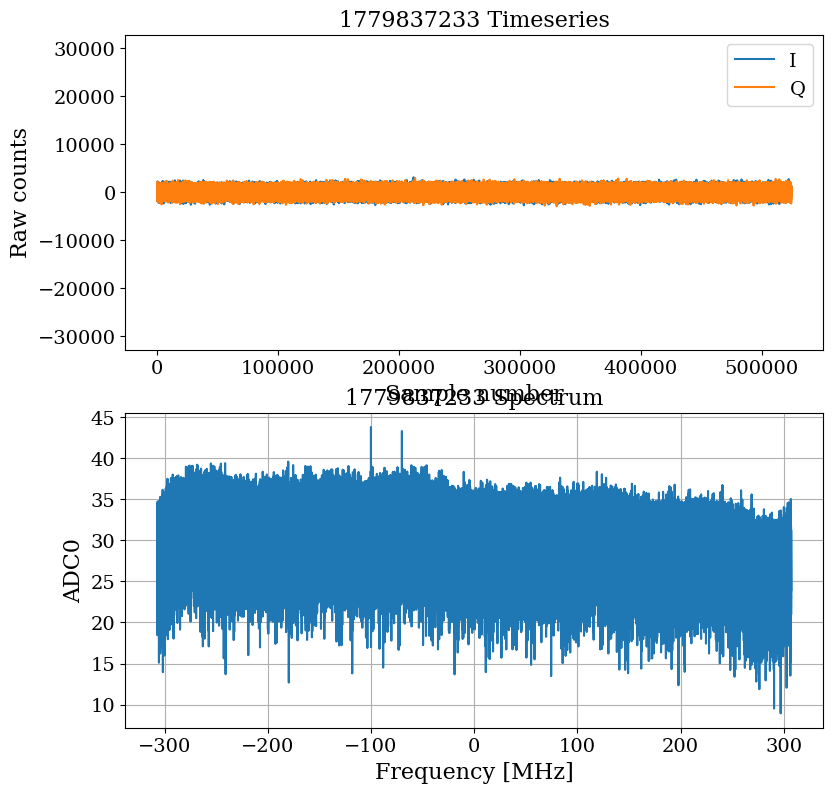

In [29]:
adc=S.read_adc_data(band = band1,make_plot=True,show_plot=True)

Ok, it looks like the two tones are there

## Streaming

In [30]:
S.get_timing_mode()

'ext_ref'

In [31]:
# S.set_timing_mode('ext_ref')

In [32]:
S.get_downsample_mode()

'internal'

In [33]:
S.set_lms_gain(band0,7)
S.set_lms_gain(band1,7)

In [34]:
from pysmurf.client.util.SmurfFileReader import SmurfStreamReader
S._caput(f'{S.app_core}baySelStream', 0, write_log=True)
S._caput(f'{S.app_core}modeStream', 1,write_log=True)
print(f"baySelStream: {S._caget(f'{S.app_core}baySelStream',write_log=True)}")
print(f"modeStream: {S._caget(f'{S.app_core}modeStream',write_log=True)}")

[ 2026-05-26 23:14:13 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream 0
[ 2026-05-26 23:14:13 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream 1
[ 2026-05-26 23:14:13 ]  caget smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream
[ 2026-05-26 23:14:13 ]  0
baySelStream: 0
[ 2026-05-26 23:14:13 ]  caget smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream
[ 2026-05-26 23:14:13 ]  1
modeStream: 1


In [35]:
S.stream_data_off()

# Sample rate (can't go above 38ish)
S.flux_ramp_setup(10,0) # first number in kHz, 2nd number only matters for uMUX

[ 2026-05-26 23:14:16 ]  caput smurf_server_s3:AMCc:SmurfProcessor:FileWriter:Close 1
[ 2026-05-26 23:14:16 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:enableStreaming 0
[ 2026-05-26 23:14:16 ]  Waiting 0.15 seconds after...
[ 2026-05-26 23:14:16 ]  Done waiting.
[ 2026-05-26 23:14:16 ]  Percent full scale = 0.000%


In [52]:
S.get_sample_frequency() #in Hz

10000.0

In [38]:
# Configure filter / downsample
S.set_filter_disable(False) # I probably want to filter?
S.set_downsample_factor(1)

print(f'S.get_sample_frequency()={S.get_sample_frequency()}')
print(f'S.get_downsample_factor()={S.get_downsample_factor()}')
print(f'S.get_filter_disable()={S.get_filter_disable()}')

S.get_sample_frequency()=10000.0
S.get_downsample_factor()=1
S.get_filter_disable()=0


In [39]:
t_stream = 5. #seconds

In [40]:
# loss counter tells you if you lost any frames btw rfsoc and pcie card.  
# Very unlikely at these channel counts, but good to check.
cnt0=S.get_frame_count()
losscnt0=S.get_frame_loss_cnt()

# Here IQ_mode tells the data-taking and read-back that we're taking data in the nonstandard I/Q mode.
data_file=S.take_stream_data(t_stream,IQ_mode=True)

cnt1=S.get_frame_count()
losscnt1=S.get_frame_loss_cnt()

[ 2026-05-26 23:14:43 ]  Starting to take data.
[ 2026-05-26 23:14:43 ]  Input downsample factor is None. Using value already in pyrogue: 1
[ 2026-05-26 23:14:43 ]  CryoCard.do_read failed, retry 1 / 5.
[ 2026-05-26 23:14:43 ]  CryoCard.do_read failed, retry 2 / 5.
[ 2026-05-26 23:14:43 ]  CryoCard.do_read failed, retry 3 / 5.
[ 2026-05-26 23:14:43 ]  CryoCard.do_read failed, retry 4 / 5.
[ 2026-05-26 23:14:43 ]  CryoCard.do_read failed, retry 5 / 5.
[ 2026-05-26 23:14:43 ]  flux_ramp_ac_dc_relay status: Failed to read from cryo card.
[ 2026-05-26 23:14:43 ]  flux_ramp_ac_dc_relay_status = None - NOT A VALID STATE.
[ 2026-05-26 23:14:48 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Unwrapper:reset 1
[ 2026-05-26 23:14:48 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Filter:reset 1
[ 2026-05-26 23:14:49 ]  Writing to file : /data/smurf_data/20260526/1779837032/outputs/1779837289.dat
[ 2026-05-26 23:14:49 ]  /data/smurf_data/20260526/1779837032/outputs/1779837289_mask.txt
[ 2026-05-26 23:1

In [41]:
print(f'Number of frames = {cnt1-cnt0}')
print(f'Number of frames lost = {losscnt1-losscnt0}')

Number of frames = 62367
Number of frames lost = 0


In [42]:
print(f'Expected {t_stream/(1./(1.e3*S.get_flux_ramp_freq()))} frames')

Expected 50000.0 frames


## Read streaming data

In [43]:
from smurf_data_loader2 import *
pyximport.install()

(None, None)

In [45]:
data_file = "/data/smurf_data/20260526/1779837032/outputs/1779837289.dat"
filesize_MB = os.path.getsize(data_file)/1024**2
print(f'file size: {filesize_MB} MB')

file size: 7.257907867431641 MB


In [46]:
d, h, m = read_smurf_data_array(data_file)

first pass read to count frames
starting to scan file
at last byte
7610468 7610468
done scanning file
found {'num_data_frames': 50040, 'num_metadata_frames': 8, 'max_channels': 4, 'max_metadata_size': 706} in file


In [47]:
d.shape

(50040, 4)

In [48]:
d_restructured = d[:, 0::2] + 1j*d[:, 1::2]

In [49]:
d_restructured.shape

(50040, 2)

In [50]:
print(S.get_channel_frequency_mhz(band0))
print(S.get_channel_frequency_mhz(band1))

2.4
2.4


In [51]:
accum_factor0=(1.e6*S.get_channel_frequency_mhz(band0))/(S.get_flux_ramp_freq()*1.e3)
bit_factor0=2**(12-S.get_lms_gain(band0))*2**(7) # this 

print(f'bit_factor0 = {bit_factor0}')
print(f'accum_factor0= {accum_factor0}')

accum_factor1=(1.e6*S.get_channel_frequency_mhz(band1))/(S.get_flux_ramp_freq()*1.e3)
bit_factor1=2**(12-S.get_lms_gain(band1))*2**(7) # this 

print(f'bit_factor1 = {bit_factor1}')
print(f'accum_factor1 = {accum_factor1}')

bit_factor0 = 4096
accum_factor0= 240.0
bit_factor1 = 4096
accum_factor1 = 240.0


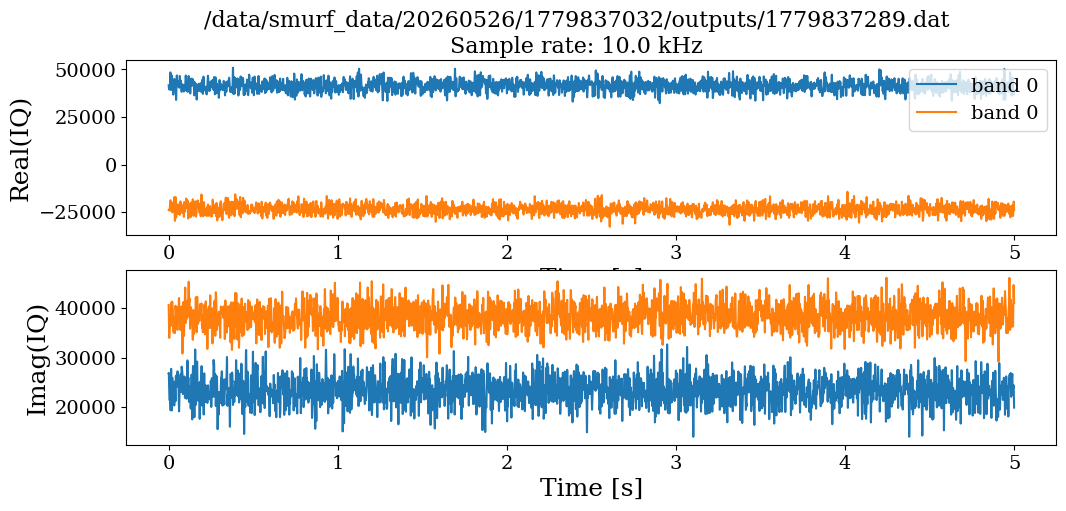

In [57]:
fs = S.get_sample_frequency()

start_plot_time_s = 0
stop_plot_time_s = 5


yoffset=20000
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5))
band = band0 #either band would work

for ch in range(len(S.which_on(band))):
    num_channel = S.which_on(band)[ch]
    
    ych=bit_factor0*d_restructured[:,ch]/accum_factor0
    ymax=np.max(ych)
    ymin=np.min(ych)
    yspan=ymax-ymin
    ymedian=np.median(ych)

    ## Find indices that best match times
    times = np.arange(len(ych)) / fs
    start_plot_idx = np.argmin(np.abs(times - start_plot_time_s))
    stop_plot_idx = np.argmin(np.abs(times - stop_plot_time_s))
    
    ax1.plot(times[start_plot_idx:stop_plot_idx], np.real(ych[start_plot_idx:stop_plot_idx]) + yoffset*ch, label = 'band 0')
    ax1.set_ylabel('Real(IQ)',fontsize=18)
    ax1.set_xlabel('Time [s]',fontsize=18)
    ax2.plot(times[start_plot_idx:stop_plot_idx], np.imag(ych[start_plot_idx:stop_plot_idx]) + yoffset*ch, label = 'band 1')
    ax2.set_ylabel('Imag(IQ)',fontsize=18)
    ax2.set_xlabel('Time [s]',fontsize=18)
    fig.suptitle(data_file+'\n'+f'Sample rate: {fs/1e3} kHz',fontsize=16)
    ax1.legend(loc = 'upper right')    
plt.show()